# Tendencia de Compra en E-commerce: Simulación con Población Colombiana

## Objetivo

Este notebook simula un estudio de mercado sobre **preferencias de compra en línea** de consumidores colombianos, 
utilizando [TinyTroupe](https://github.com/microsoft/TinyTroupe) para generar una población sintética diversa 
y evaluar sus decisiones de compra ante dos opciones de e-commerce con perfiles de riesgo y precio distintos.

### Escenario de investigación

Se presenta a los agentes un dilema de compra realista:
- **Opción 1**: Comprar una lavadora en una tienda local/informal, significativamente más barata, con pago en efectivo, 
  pero sin garantías formales ni respaldo de plataforma.
- **Opción 2**: Comprar la misma lavadora en Mercado Libre, más costosa, pero con beneficios como garantía, 
  devolución fácil, financiación y respaldo del vendedor.

El objetivo es entender **qué factores influyen** en la decisión de cada segmento de la población, 
y extraer insights accionables para decisiones de negocio.

### Contexto psicológico

Según la literatura en Psicología del Consumidor, las decisiones de compra son influenciadas por factores como 
la **aversión al riesgo**, la **sensibilidad al precio**, la **confianza institucional**, y las 
**normas culturales** del entorno del comprador (Kahneman & Tversky, 1979; Hofstede, 2001). 
En Colombia, la economía informal y la cultura de compra local son factores relevantes que pueden 
contrarrestar las ventajas percibidas de plataformas digitales.

In [1]:
# Bibliotecas estándar y de visualización
import json
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

sys.path.insert(0, '..')

# TinyTroupe: simulación de comportamiento humano
import tinytroupe
from tinytroupe import config_manager
from tinytroupe.agent import TinyPerson
from tinytroupe.environment import TinyWorld
from tinytroupe.factory import TinyPersonFactory
from tinytroupe.validation import TinyPersonValidator
from tinytroupe import control

from tinytroupe.extraction import ResultsExtractor
from tinytroupe.profiling import Profiler


!!!!
DISCLAIMER: TinyTroupe relies on Artificial Intelligence (AI) models to generate content. 
The AI models are not perfect and may produce inappropriate or inaccurate results. 
For any serious or consequential use, please review the generated content before using it.
!!!!

Looking for default config on: c:\Users\pdasilva\repos\TinyTroupe\examples\..\tinytroupe\utils\..\config.ini
Found custom config on: c:\Users\pdasilva\repos\TinyTroupe\examples\config.ini
TinyTroupe version: 0.6.0
Current date and time (local): 2026-02-18 20:29:55
Current date and time (UTC):   2026-02-18 23:29:55

Current TinyTroupe configuration 
[OpenAI]
api_type = openai
azure_api_version = 2024-08-01-preview
model = gpt-5-mini
reasoning_model = o3-mini
vision_detail = auto
embedding_model = text-embedding-3-small
azure_embedding_model_api_version = 2023-05-15
max_completion_tokens = 128000
timeout = 480
max_attempts = 5
waiting_time = 0
exponential_backoff_factor = 5
max_concurrent_model_calls = 4
reasoning_

In [2]:
# Iniciar control de caché para evitar llamadas LLM repetidas
control.begin("tendencia-compra-ecomerce.cache.json")

# Parámetros del experimento
target_nationality = "Colombia"
population_size = 30

# Cargar especificación demográfica adicional con dimensiones de muestreo
with open("./information/populations/colombia_extra_info.txt", "r", encoding="utf-8") as f:
    additional_demographic_specification = f.read()

In [3]:
##############################################################################
# Diseño de la encuesta
#
# La clave para obtener respuestas diversas y realistas es:
# 1. Presentar un dilema genuino donde ambas opciones tengan ventajas claras
# 2. Enfatizar la diferencia de precio en términos concretos (COP)
# 3. Usar un monólogo interno que normalice ambas elecciones
# 4. Evitar sesgar la pregunta hacia una respuesta "correcta"
##############################################################################

interviewer_introduction = """
Hola, soy parte de un equipo de investigación que estudia cómo las personas en Colombia 
toman decisiones de compra. No hay respuestas correctas ni incorrectas: solo queremos 
entender cómo piensas al decidir. Cuéntanos un poco sobre ti: tu situación económica actual, 
cómo sueles comprar electrodomésticos, y si confías más en tiendas físicas locales o en 
plataformas de internet.
"""

interviewer_main_question = """
Imagina que necesitas comprar una lavadora. Encuentras dos opciones del mismo modelo exacto:

**Opción 1 – Tienda local / vendedor independiente:**
- Precio: $990.000 COP (10% menos que en Mercado Libre, con descuento adicional si pagas en efectivo).
- Es una tienda de barrio que te recomendó un vecino. El dueño te ofrece instalación gratis.
- No tiene página web ni calificaciones en línea, pero lleva años en el barrio.
- Sin política formal de devolución ni garantía escrita, aunque el dueño dice que "responde si hay problemas".

**Opción 2 – Mercado Libre (vendedor con buena reputación):**
- Precio: $1.100.000 COP (puede pagarse en 12 cuotas sin interés con tarjeta de crédito).
- Entrega garantizada en 3-5 días, devolución fácil en 30 días, garantía formal del fabricante.
- Vendedor con más de 500 ventas y calificación de 4.8/5.
- No incluye instalación.

¿Cuál opción elegirías? Responde con "Opción 1" u "Opción 2" y explica tus razones 
considerando tu situación personal, económica y tu forma de pensar al comprar. 
Recuerda: NO hay respuesta correcta. Ambas opciones son válidas y la gente real 
elige de formas muy distintas según sus circunstancias.
"""

# Monólogo interno: se entrega como pensamiento propio del agente (broadcast_thought).
# Esto es crítico para obtener respuestas diversas y honestas, ya que permite al agente
# razonar desde su propia perspectiva antes de responder.
inner_monologue = """
Voy a pensar con total honestidad, como si esta situación me pasara de verdad en mi vida.

Primero consideraré mi situación REAL:
- ¿Cuánto dinero tengo disponible ahora mismo? ¿Tengo tarjeta de crédito o no?
- ¿$110.000 COP de diferencia es mucho o poco para mí?
- ¿He tenido buenas o malas experiencias comprando en tiendas locales o por internet?
- ¿Confío más en un vecino que me recomienda algo, o en las calificaciones de internet?
- ¿Qué tan importante es para mí tener garantía formal vs. confiar en la palabra del vendedor?

Está BIEN elegir la opción más barata si así es como yo realmente compraría. 
Muchas personas sensatas prefieren ahorrar dinero y confiar en su comunidad local.
También está BIEN elegir la opción más costosa si valoro la seguridad y la garantía.
No debo sentir presión por elegir una u otra: debo ser fiel a quien soy.

Ahora voy a PENSAR profundamente... y luego HABLARÉ con mi respuesta honesta.
"""

In [4]:
# Extractor de resultados: convierte las respuestas de los agentes en datos estructurados
results_extractor = ResultsExtractor(
    extraction_objective=(
        "Determinar cuál opción de compra prefiere cada persona: "
        "Opción 1 (tienda local, más barata, sin garantía formal) u "
        "Opción 2 (Mercado Libre, más costosa, con garantías y beneficios)."
    ),
    situation=(
        "El agente fue consultado sobre cuál oferta preferiría al comprar una lavadora: "
        "Opción 1 a $990.000 COP en tienda local de barrio (10% más barata, recomendada por vecino, "
        "sin garantía formal), u Opción 2 a $1.100.000 COP en Mercado Libre (más costosa, con "
        "garantía, devolución fácil, financiación a cuotas). "
        "El agente debía indicar su elección ('1' o '2') y justificarla."
    ),
    fields=["name", "response", "justification"],
    fields_hints={
        "response": (
            "Debe ser exactamente '1', '2' o 'N/A' (si no se puede determinar la elección). "
            "No aceptes otros formatos como 'uno', 'dos', 'Opción 1', etc."
        ),
        "justification": (
            "Resumen breve (1-2 oraciones) de la razón principal por la que eligió esa opción."
        )
    },
    verbose=True
)

In [5]:
##############################################################################
# Funciones de análisis
##############################################################################

def analizar_resultados_simulacion(df):
    """
    Analiza y visualiza las respuestas simuladas sobre preferencias de compra.
    Genera un gráfico de barras y un resumen estadístico.
    """
    df["response"] = df["response"].astype(str)
    counts = df["response"].value_counts().reindex(["1", "2", "N/A"], fill_value=0)
    total = counts.sum()

    # --- Gráfico de barras ---
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = {"1": "#FF8C42", "2": "#4A90D9", "N/A": "#CCCCCC"}
    labels = {
        "1": f"Opción 1\nTienda local\n($990K COP)\n{counts.get('1', 0)} votos",
        "2": f"Opción 2\nMercado Libre\n($1.1M COP)\n{counts.get('2', 0)} votos",
        "N/A": f"N/A\n{counts.get('N/A', 0)} votos"
    }

    bars = ax.bar(
        [labels[k] for k in counts.index],
        counts.values,
        color=[colors[k] for k in counts.index],
        edgecolor="white",
        linewidth=1.5
    )

    # Añadir porcentajes sobre las barras
    for bar, count in zip(bars, counts.values):
        if count > 0:
            pct = count / total * 100
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                    f"{pct:.0f}%", ha="center", va="bottom", fontsize=13, fontweight="bold")

    ax.set_ylabel("Número de respuestas", fontsize=12)
    ax.set_title("Preferencia de Compra: Tienda Local vs. Mercado Libre\n(Población colombiana simulada)",
                 fontsize=13, fontweight="bold")
    ax.set_ylim(0, max(counts.values) * 1.3 if max(counts.values) > 0 else 5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    # --- Resumen textual ---
    print(f"\n{'='*60}")
    print(f"  RESULTADOS DE LA SIMULACIÓN DE PREFERENCIA DE COMPRA")
    print(f"{'='*60}")
    print(f"  Total de respuestas: {total}")
    print(f"  Opción 1 (tienda local, $990K): {counts.get('1', 0)} ({counts.get('1', 0)/total:.0%})")
    print(f"  Opción 2 (Mercado Libre, $1.1M): {counts.get('2', 0)} ({counts.get('2', 0)/total:.0%})")
    if counts.get("N/A", 0) > 0:
        print(f"  N/A: {counts.get('N/A', 0)} ({counts.get('N/A', 0)/total:.0%})")
    print(f"{'='*60}\n")


def analizar_razones_por_grupo(df):
    """
    Extrae y presenta las razones principales de cada grupo de respuesta.
    Útil para tomar decisiones de negocio basadas en los motivos de cada segmento.
    """
    df["response"] = df["response"].astype(str)

    for opcion, descripcion in [("1", "Opción 1 – Tienda local ($990K COP)"),
                                 ("2", "Opción 2 – Mercado Libre ($1.1M COP)")]:
        grupo = df[df["response"] == opcion]
        if grupo.empty:
            continue

        print(f"\n{'─'*60}")
        print(f"  {descripcion}")
        print(f"  {len(grupo)} persona(s) eligieron esta opción")
        print(f"{'─'*60}")

        # Mostrar cada justificación con el nombre del agente
        for i, (_, row) in enumerate(grupo.iterrows(), 1):
            nombre = row.get("name", "Agente")
            justificacion = row.get("justification", "Sin justificación")
            # Envolver texto largo para legibilidad
            wrapped = textwrap.fill(str(justificacion), width=70, initial_indent="    ",
                                    subsequent_indent="    ")
            print(f"\n  {i}. {nombre}:")
            print(wrapped)

    print(f"\n{'═'*60}")
    print("  RESUMEN PARA DECISIONES DE NEGOCIO")
    print(f"{'═'*60}")

    n1 = len(df[df["response"] == "1"])
    n2 = len(df[df["response"] == "2"])
    total = n1 + n2

    if total > 0 and n1 > 0 and n2 > 0:
        print(f"""
  • {n1}/{total} ({n1/total:.0%}) prefiere la tienda local: estos consumidores priorizan
    el precio y la confianza comunitaria sobre las garantías formales.

  • {n2}/{total} ({n2/total:.0%}) prefiere Mercado Libre: estos consumidores valoran 
    la seguridad, garantías y la conveniencia de la plataforma digital.

  → Para capturar al segmento sensible al precio, considere ofrecer precios
    competitivos, opciones de pago en efectivo y presencia local.
  → Para el segmento digital, refuerce la reputación, garantías y opciones
    de financiación.
        """)
    elif n1 == 0:
        print("\n  Todos los agentes prefirieron Mercado Libre. Considere ajustar")
        print("  el escenario para representar mejor la diversidad de opiniones.\n")
    elif n2 == 0:
        print("\n  Todos los agentes prefirieron la tienda local. Considere ajustar")
        print("  el escenario para representar mejor la diversidad de opiniones.\n")

In [6]:
# Crear la fábrica de personajes a partir del perfil demográfico colombiano.
# Las dimensiones adicionales (colombia_extra_info.txt) incluyen actitud general,
# nivel educativo, hábitos de compra, estilo de vida, etc., que producen una
# población diversa con distintas sensibilidades al precio y confianza digital.
factory = TinyPersonFactory.create_factory_from_demography(
    "./information/populations/colombia.json",
    population_size=population_size,
    additional_demographic_specification=additional_demographic_specification
)

## Construcción de la audiencia

Generamos la población sintética colombiana. Cada agente tendrá un perfil demográfico 
único que incluye nivel socioeconómico, hábitos de compra, actitud general, nivel educativo, 
y otros factores que influyen en sus decisiones de consumo.

In [7]:
# Generar los agentes con perfiles diversos
people = factory.generate_people(population_size, verbose=True)

In [8]:
# Verificar las dimensiones de muestreo usadas para generar la población
factory.sampling_dimensions

{'sampling_space_description': 'Colombian population (~52.7 million, 2024 est.). Detailed sampling space capturing age, sex, ethnicity, geography, education, income quintiles, employment sectors, urban/rural split, major cities, personality archetypes, political and economic beliefs, cultural background and influences, culinary preferences, shopping and technology habits, travel and lifestyle patterns, health consciousness, public opinion on major social problems, migrant presence (including Venezuelan migrants), and many fine-grained subjective attributes so that generated individuals are realistic and representative according to the demographic data provided.',
 'dimensions': [{'name': 'age', 'range': [0, 100]},
  {'name': 'age_group',
   'values': {'0-14 years: Children and young adolescents, typically living in family households, attending school or early education.': 0.255,
    '15-24 years: Older adolescents and young adults, many in secondary or tertiary education, entering the 

[DEBUG facet:interests] agents=30 raw_tokens=0 sample=[]
[DEBUG normalize:interests] No tokens provided.
[DEBUG distribution] agents=30 mapping_clusters=0 rev_lookup_size=0
[DEBUG distribution] total_raw_tokens=0
[DEBUG distribution] No mapping available -> raw frequency fallback.
[DEBUG distribution] No flat tokens after flattening.
[DEBUG facet:interests] categories= []
DEBUG Skills: skills_per_agent sample: [['Advanced competence in preparing a wide repertoire of traditional Colombian dishes (tamales, sancocho, bandeja basics, empanadas, arepas, arroz con pollo).', 'Portion control and recipe scaling for small catering events and market sales.', 'Household budgeting and prioritizing expenses across a month using an envelope system.', 'Basic bookkeeping: records daily sales, monthly expenses, and savings goals in a paper notebook.', 'Caregiving skills for elderly family members: medication reminders, simple mobility assistance, and appointment scheduling.', 'Childcare and early super

c:\Users\pdasilva\repos\TinyTroupe\examples\..\tinytroupe\profiling.py:1116: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


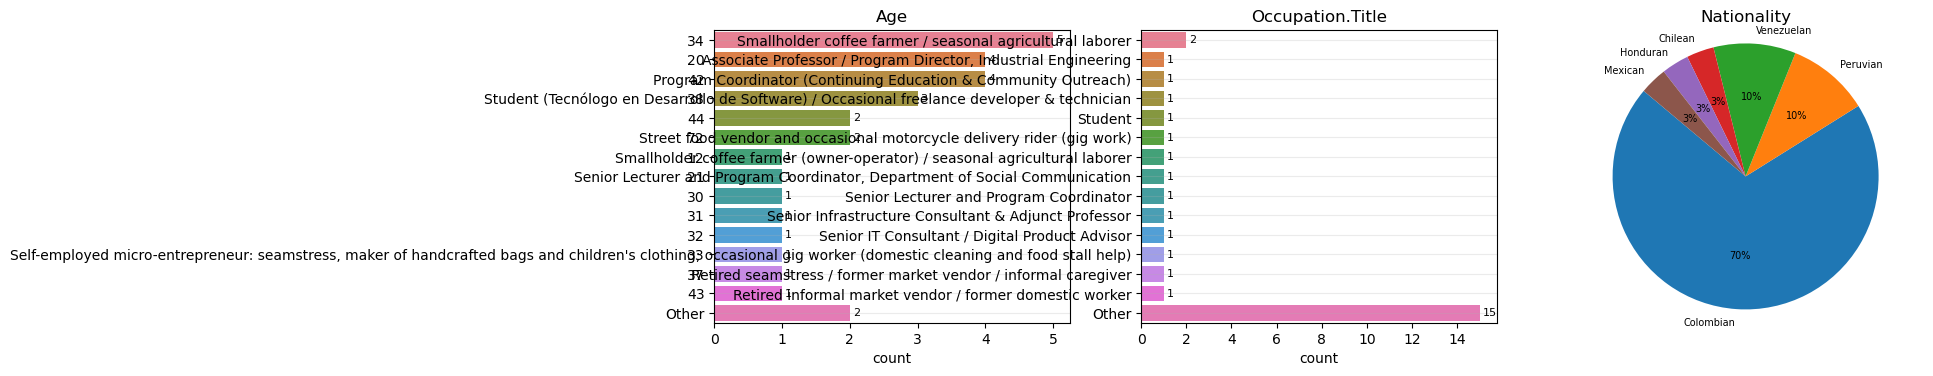

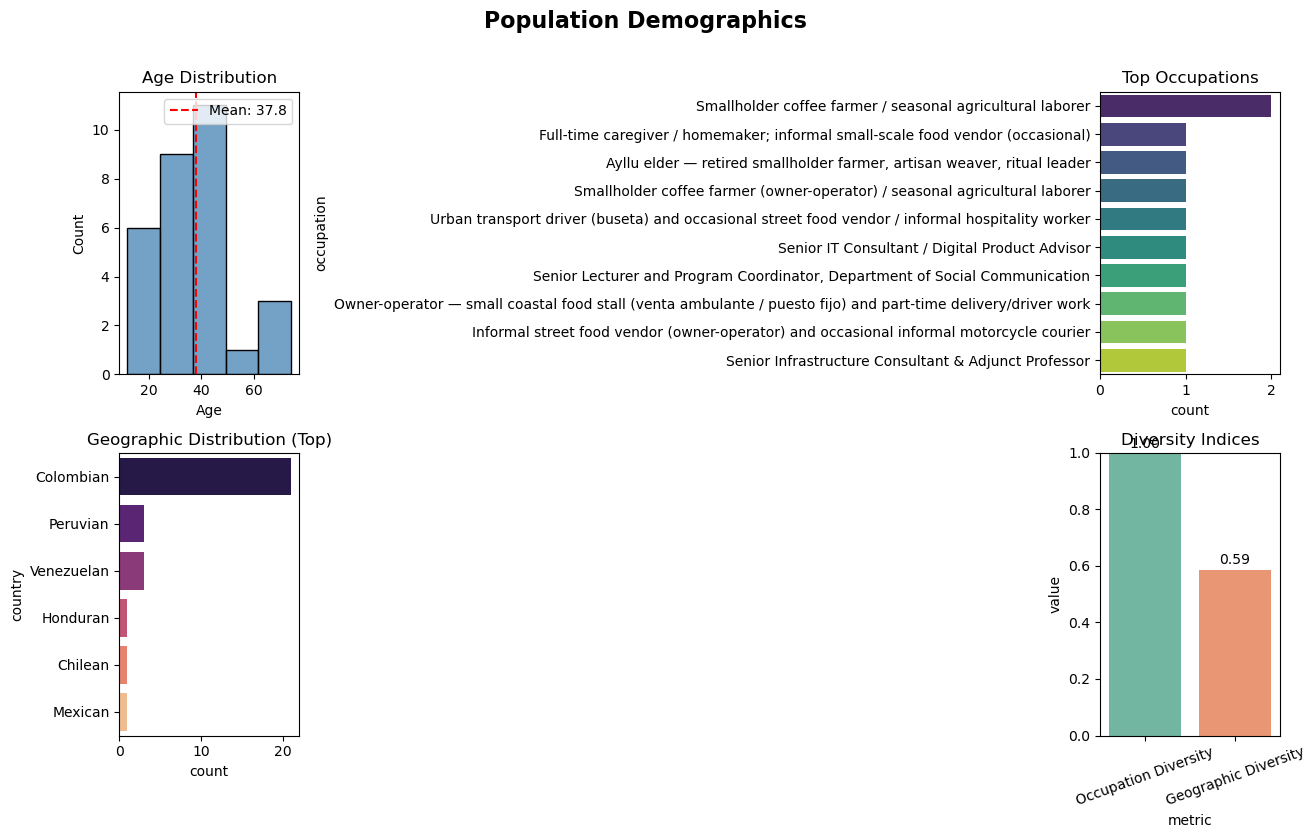

Persona composition keys found: ['interests', 'skills', 'beliefs', 'goals', 'likes_dislikes', 'routines', 'relationship_roles', 'communication_style', 'health', 'personality_traits']
[DEBUG persona_plot] facet 'interests' empty -> hidden
[DEBUG persona_plot] facet 'goals' empty -> hidden
[DEBUG persona_plot] facet 'likes_dislikes' empty -> hidden
[DEBUG persona_plot] facet 'relationship_roles' empty -> hidden
[DEBUG persona_plot] facet 'health' empty -> hidden


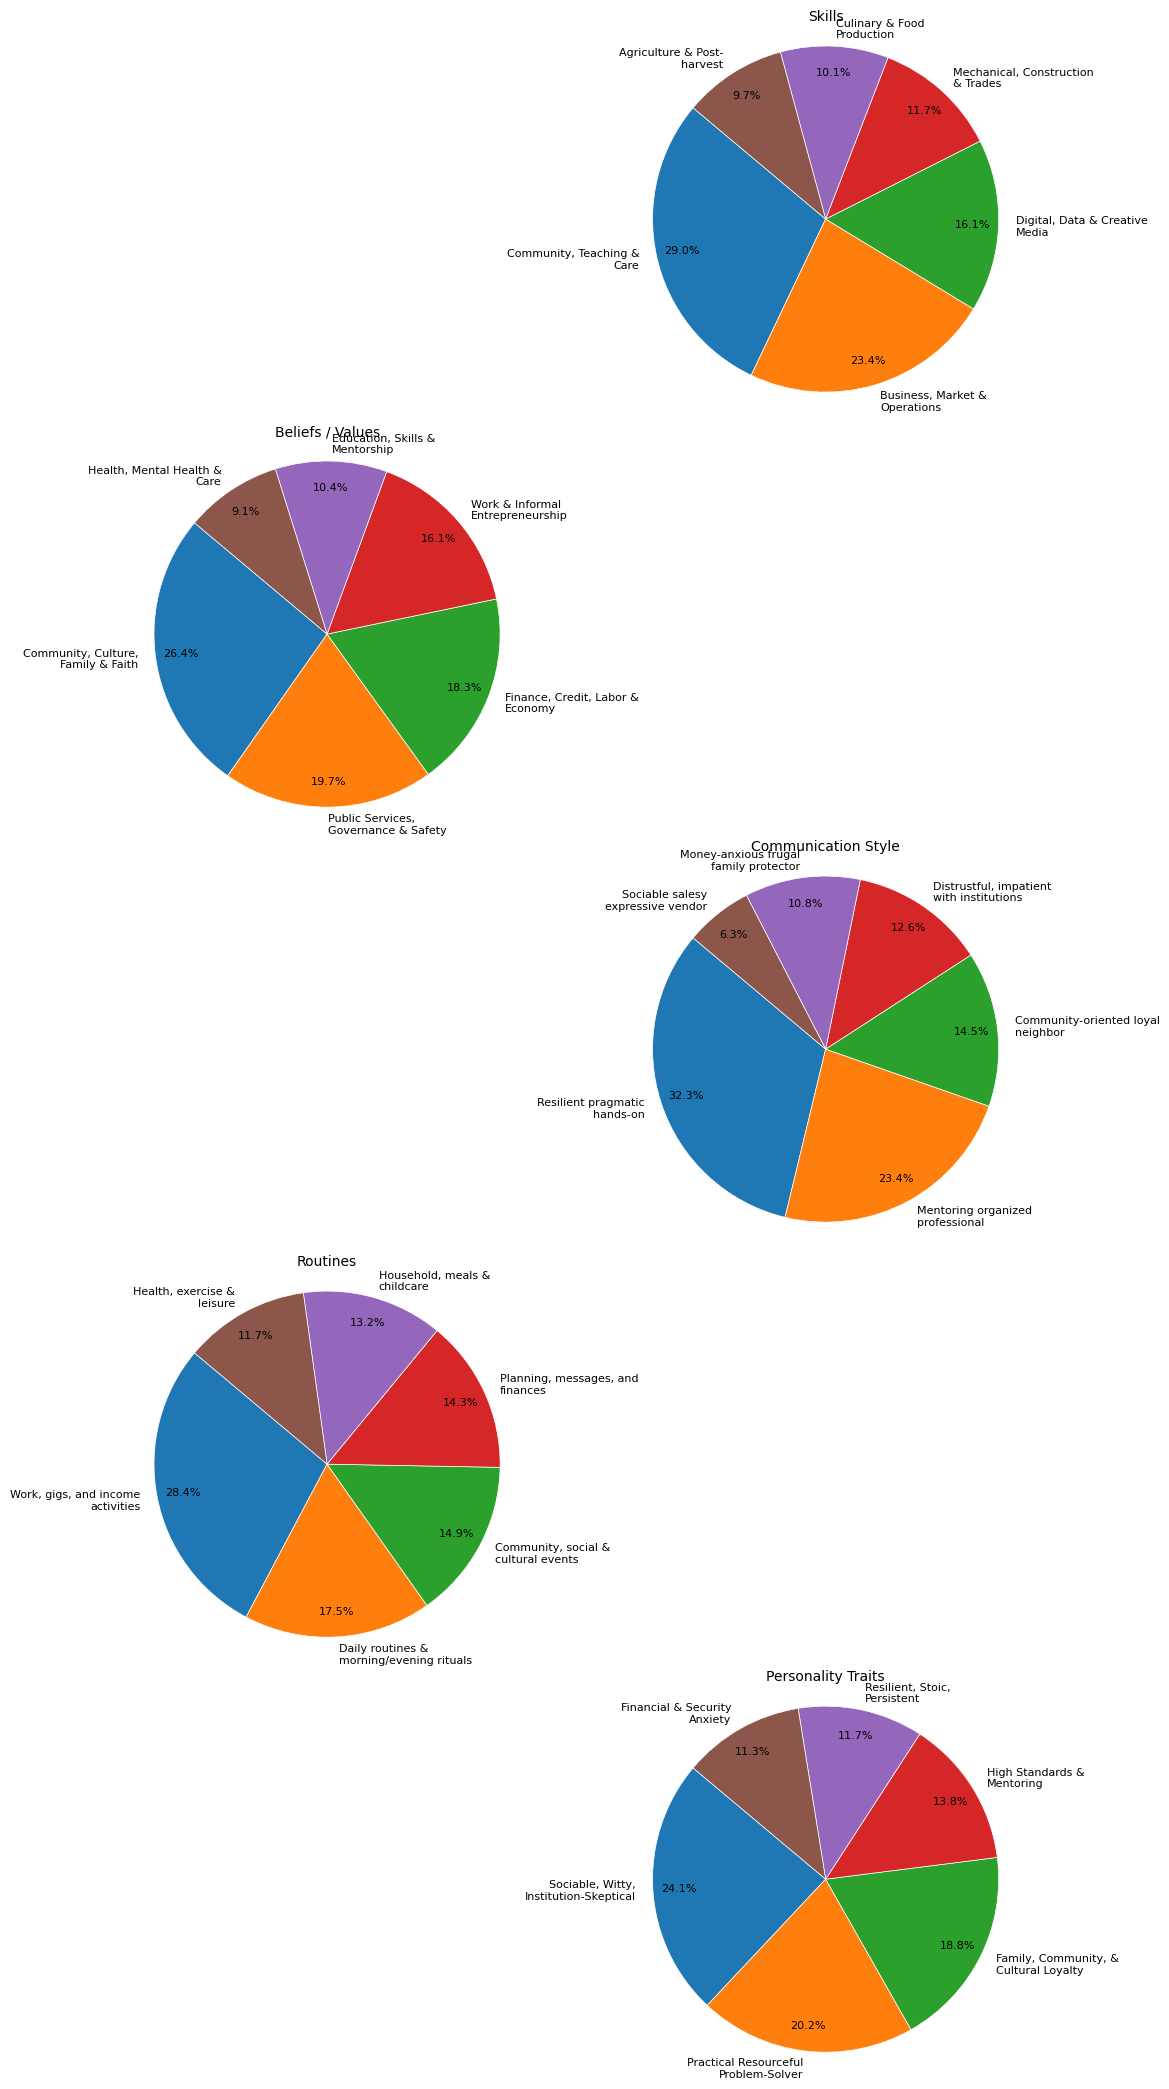

In [9]:
# Perfilar la población generada para verificar diversidad demográfica
profiler = Profiler()
profiler.profile(people)

# Guardar progreso en caché
control.checkpoint()

# Crear el ambiente de simulación.
# broadcast_if_no_target=False evita que los agentes se influencien entre sí,
# lo cual es esencial en encuestas para obtener respuestas independientes.
audiencia = TinyWorld(f"Target audience ({target_nationality})", people, broadcast_if_no_target=False)

## Ejecución del experimento

Presentamos la encuesta a todos los agentes simultáneamente. El flujo es:
1. **Introducción** (`broadcast`) — contexto externo del entrevistador
2. **Pregunta principal** (`broadcast`) — el dilema de compra
3. **Monólogo interno** (`broadcast_thought`) — se inyecta como pensamiento propio del agente, 
   para que razone desde su perspectiva personal antes de responder
4. **Ejecución** (`run(1)`) — el agente procesa todos los estímulos y genera su respuesta

In [10]:
# Enviar estímulos a todos los agentes
audiencia.broadcast(interviewer_introduction)
audiencia.broadcast(interviewer_main_question)
audiencia.broadcast_thought(inner_monologue)

USER --> Mariana Isabel Gómez Ramírez: [CONVERSATION] 
          >  Hola, soy parte de un equipo de investigación que estudia cómo las personas en Colombia
          > toman decisiones de compra. No hay respuestas correctas ni incorrectas: solo queremos
          > entender cómo piensas al decidir. Cuéntanos un poco sobre ti: tu situación económica
          > actual,  cómo sueles comprar electrodomésticos, y si confías más en tiendas físicas
          > locales o en  plataformas de internet.

       + --> Natalia Marcela Salazar Ocampo

       + --> Jhon Jairo Castillo Guzmán

       + --> ...others...

USER --> Mariana Isabel Gómez Ramírez: [CONVERSATION] 
          >  Imagina que necesitas comprar una lavadora. Encuentras dos opciones del mismo modelo
          > exacto:  **Opción 1 – Tienda local / vendedor independiente:** - Precio: $990.000 COP
          > (10% menos que en Mercado Libre, con descuento adicional si pagas en efectivo). - Es una
          > tienda de barrio que te recomendó un vecino. El dueño te ofrece instalación gratis. - No
          > tiene página web ni calificaciones en línea, pero lleva años en el barrio. - Sin
          > política formal de devolución ni garantía escrita, aunque el dueño dice que "responde si
          > hay problemas".  **Opción 2 – Mercado Libre (vendedor con buena reputación):** - Precio:
          > $1.100.000 COP (puede pagarse en 12 cuotas sin interés con tarjeta de crédito). -
          > Entrega garantizada en 3-5 días, devolución fácil en 30 días, garantía formal del
          > fabricante. - Vendedor con más de 500 ventas y calificación de 4.8/5. - No incluye
          > instalación.  ¿Cuál opción elegirías? Responde con "Opción 1" u "Opción 2" y explica tus
          > razones  considerando tu situación personal, económica y tu forma de pensar al  (...)

...

Santiago Andrés Mejía Restrepo --> Santiago Andrés Mejía Restrepo: [THOUGHT] 
                                    >  Voy a pensar con total honestidad, como si esta situación me
                                    > pasara de verdad en mi vida.  Primero consideraré mi situación
                                    > REAL: - ¿Cuánto dinero tengo disponible ahora mismo? ¿Tengo
                                    > tarjeta de crédito o no? - ¿$110.000 COP de diferencia es
                                    > mucho o poco para mí? - ¿He tenido buenas o malas experiencias
                                    > comprando en tiendas locales o por internet? - ¿Confío más en
                                    > un vecino que me recomienda algo, o en las calificaciones de
                                    > internet? - ¿Qué tan importante es para mí tener garantía
                                    > formal vs. confiar en la palabra del vendedor?  Está BIEN
                                    > elegir la opción más barata si así es como yo realmente
                                    > compraría.  Muchas personas sensatas prefieren ahorrar dinero
                                    > y confiar en su comunidad local. También está BIEN elegir la
                                    > opción más costosa si valoro la seguridad y la garantía. No
                                    > debo sentir presión por elegir una u otra: debo ser fiel a
                                    > quien soy.  Ahora voy a PENSAR profundamente... y luego
                                    > HABLARÉ con mi respuesta honesta.

Yuliana Marcela Rojas Fernández --> Yuliana Marcela Rojas Fernández: [THOUGHT] 
                                     >  Voy a pensar con total honestidad, como si esta situación me
                                     > pasara de verdad en mi vida.  Primero consideraré mi
                                     > situación REAL: - ¿Cuánto dinero tengo disponible ahora
                                     > mismo? ¿Tengo tarjeta de crédito o no? - ¿$110.000 COP de
                                     > diferencia es mucho o poco para mí? - ¿He tenido buenas o
                                     > malas experiencias comprando en tiendas locales o por
                                     > internet? - ¿Confío más en un vecino que me recomienda algo,
                                     > o en las calificaciones de internet? - ¿Qué tan importante es
                                     > para mí tener garantía formal vs. confiar en la palabra del
                                     > vendedor?  Está BIEN elegir la opción más barata si así es
                                     > como yo realmente compraría.  Muchas personas sensatas
                                     > prefieren ahorrar dinero y confiar en su comunidad local.
                                     > También está BIEN elegir la opción más costosa si valoro la
                                     > seguridad y la garantía. No debo sentir presión por elegir
                                     > una u otra: debo ser fiel a quien soy.  Ahora voy a PENSAR
                                     > profundamente... y luego HABLARÉ con mi respuesta honesta.

Juan Pablo Torres Cárdenas --> Juan Pablo Torres Cárdenas: [THOUGHT] 
                                >  Voy a pensar con total honestidad, como si esta situación me
                                > pasara de verdad en mi vida.  Primero consideraré mi situación
                                > REAL: - ¿Cuánto dinero tengo disponible ahora mismo? ¿Tengo
                                > tarjeta de crédito o no? - ¿$110.000 COP de diferencia es mucho o
                                > poco para mí? - ¿He tenido buenas o malas experiencias comprando
                                > en tiendas locales o por internet? - ¿Confío más en un vecino que
                                > me recomienda algo, o en las calificaciones de internet? - ¿Qué
                                > tan importante es para mí tener garantía formal vs. confiar en la
                                > palabra del vendedor?  Está BIEN elegir la opción más barata si
                                > así es como yo realmente compraría.  Muchas personas sensatas
                                > prefieren ahorrar dinero y confiar en su comunidad local. También
                                > está BIEN elegir la opción más costosa si valoro la seguridad y la
                                > garantía. No debo sentir presión por elegir una u otra: debo ser
                                > fiel a quien soy.  Ahora voy a PENSAR profundamente... y luego
                                > HABLARÉ con mi respuesta honesta.

María Elena Morales Gutiérrez --> María Elena Morales Gutiérrez: [THOUGHT] 
                                   >  Voy a pensar con total honestidad, como si esta situación me
                                   > pasara de verdad en mi vida.  Primero consideraré mi situación
                                   > REAL: - ¿Cuánto dinero tengo disponible ahora mismo? ¿Tengo
                                   > tarjeta de crédito o no? - ¿$110.000 COP de diferencia es mucho
                                   > o poco para mí? - ¿He tenido buenas o malas experiencias
                                   > comprando en tiendas locales o por internet? - ¿Confío más en
                                   > un vecino que me recomienda algo, o en las calificaciones de
                                   > internet? - ¿Qué tan importante es para mí tener garantía
                                   > formal vs. confiar en la palabra del vendedor?  Está BIEN
                                   > elegir la opción más barata si así es como yo realmente
                                   > compraría.  Muchas personas sensatas prefieren ahorrar dinero y
                                   > confiar en su comunidad local. También está BIEN elegir la
                                   > opción más costosa si valoro la seguridad y la garantía. No
                                   > debo sentir presión por elegir una u otra: debo ser fiel a
                                   > quien soy.  Ahora voy a PENSAR profundamente... y luego HABLARÉ
                                   > con mi respuesta honesta.

Diego Alejandro Paredes Morales --> Diego Alejandro Paredes Morales: [THOUGHT] 
                                     >  Voy a pensar con total honestidad, como si esta situación me
                                     > pasara de verdad en mi vida.  Primero consideraré mi
                                     > situación REAL: - ¿Cuánto dinero tengo disponible ahora
                                     > mismo? ¿Tengo tarjeta de crédito o no? - ¿$110.000 COP de
                                     > diferencia es mucho o poco para mí? - ¿He tenido buenas o
                                     > malas experiencias comprando en tiendas locales o por
                                     > internet? - ¿Confío más en un vecino que me recomienda algo,
                                     > o en las calificaciones de internet? - ¿Qué tan importante es
                                     > para mí tener garantía formal vs. confiar en la palabra del
                                     > vendedor?  Está BIEN elegir la opción más barata si así es
                                     > como yo realmente compraría.  Muchas personas sensatas
                                     > prefieren ahorrar dinero y confiar en su comunidad local.
                                     > También está BIEN elegir la opción más costosa si valoro la
                                     > seguridad y la garantía. No debo sentir presión por elegir
                                     > una u otra: debo ser fiel a quien soy.  Ahora voy a PENSAR
                                     > profundamente... y luego HABLARÉ con mi respuesta honesta.

In [11]:
# Ejecutar la simulación: cada agente procesa los estímulos y responde.
# Usamos run(1) — un solo paso — para evitar que los agentes converjan
# en sus respuestas al tener múltiples rondas de reflexión.
audiencia.run(1)

# Guardar estado de la simulación
control.checkpoint()

───────────────────────────────────── Target audience (Colombia) step 1 of 1 ──────────────────────────────────────

Juana Ñusta Quispe Mamani acts: [THINK] 
                               > Pienso en lo que escribí. ¿Cuánto tengo ahora? No tengo tarjeta de
                               > crédito como la gente de la ciudad. Para mí, 110.000 pesos es mucho
                               > dinero —es como una bolsa de semillas buena para la siembra. Si el
                               > vecino recomienda la tienda y el dueño es conocido, la palabra
                               > vale. Me sirve que ofrezcan instalación gratis; no puedo cargar la
                               > máquina sola ni entender manuales en letra pequeña. Pero me
                               > preocupa que no haya garantía por escrito; las palabras se las
                               > lleva el viento si hay problemas. Así que mi preferencia es:
                               > escoger la tienda local si la gente la conoce y puedo ver la
                               > lavadora funcionando antes de pagar. Si el vendedor es desconocido
                               > o desconfío, prefiero pagar un poco más por la garantía formal que
                               > Mercado Libre da. En resumen: confío primero en la comunidad, pero
                               > pido prueba y compromiso por si acaso.

Juana Ñusta Quispe Mamani acts: [TALK] 
                               > Opción 1. Prefiero la tienda local recomendada si el vecino la
                               > conoce. Pago en efectivo si puedo y me hace descuento; me da
                               > confianza la instalación gratis y la palabra del dueño. Antes de
                               > pagar, le pediría que me muestre la máquina funcionando y que me
                               > explique qué hará si se descompone. Si el vendedor fuera
                               > desconocido o no quisiera comprometerse, entonces elegiría Opción 2
                               > por la garantía escrita y la devolución fácil.

Juana Ñusta Quispe Mamani acts: [DONE] 
                               > Hecho: pensé y respondí con honestidad.

Andrés Manuel Santamaría Londoño acts: [THINK] 
                                      > Voy a razonar paso a paso, con honestidad, como si fuera una
                                      > decisión real para mi hogar.  1) Recursos y tolerancia al
                                      > riesgo: puedo asumir una diferencia de $110.000 COP sin
                                      > comprometer mis finanzas personales; además tengo tarjeta y
                                      > opciones de pago. Soy prudente con equipos que implican
                                      > servicio y mantenimiento.  2) Valor del tiempo y costos
                                      > ocultos: si la lavadora tiene un defecto o requiere
                                      > repuestos, resolverlo con un vendedor formal (garantía
                                      > escrita, política de devolución) suele ser mucho menos
                                      > costoso en tiempo y molestias. Como consultor y profesor,
                                      > valoro minimizar trámites que consumen tiempo productivo.
                                      > 3) Confianza local vs. garantía formal: aprecio apoyar
                                      > negocios de barrio y la recomendación de un vecino tiene
                                      > peso. Sin embargo, la ausencia de garantía escrita y de una
                                      > política formal es una debilidad importante para un
                                      > electrodoméstico que puede fallar. "Que responde si hay
                                      > problemas" es una promesa débil frente a un documento
                                      > formal.  4) Instalación: la opción local ofrece instalación
                                      > grat (...)

...

Diego Alejandro Paredes Morales acts: [TALK] 
                                     > Opción 1. Prefiero la tienda local: no tengo tarjeta y
                                     > necesito el descuento en efectivo; además la instalación
                                     > gratis me ahorra plata y tiempo. Confío más en la palabra de
                                     > un vecino recomendado que en una plataforma si no puedo pagar
                                     > en cuotas. Pero lo haría con cuidado: que me muestren la
                                     > lavadora funcionando, que me den un recibo con nombre y
                                     > teléfono, y preguntar a dos vecinos si ya compraron con ese
                                     > señor. Si la tienda acepta algún comprobante por escrito y
                                     > prueba inmediata, me siento cómodo. Si tuviera más dinero o
                                     > tarjeta, escogería Mercado Libre por la garantía formal, pero
                                     > ahora no puedo arriesgarme a pagar más cuando cada sol que
                                     > ahorro lo envío a mi casa. Poco a poco, que no es poco.

Diego Alejandro Paredes Morales acts: [DONE] 
                                     > Listo, respondí con mi elección y las razones.

María Elena Morales Gutiérrez acts: [THINK] 
                                   > Voy a ordenar mis ideas como lo haría en la cocina: paso por
                                   > paso. Primero: yo prefiero pagar en efectivo y uso mi libreta
                                   > para ver si alcanza; no solemos tener tarjeta de crédito para
                                   > pagar en 12 cuotas, así que la ventaja de Mercado Libre
                                   > (cuotas) probablemente no aplique para mí. La diferencia de
                                   > $110.000 COP me suena como una cantidad importante: con eso
                                   > compro una buena parte de la despensa del mes o pago varias
                                   > cuentas —no es una nimiedad en un hogar como el mío. Por otro
                                   > lado, el dueño de la tienda del barrio me lo ofrece más barato
                                   > y con instalación incluida; valoro mucho que me lo pongan y me
                                   > lo expliquen en la casa, y confío en recomendaciones de vecinos
                                   > cuando el vendedor lleva años en el barrio. Pero también me
                                   > preocupa la falta de garantía escrita: "la palabra" está bien,
                                   > pero quiero algo de seguridad para no quedarme sin respuesta si
                                   > la máquina falla. Entonces pienso en una solución intermedia:
                                   > elegir la tienda local si puedo verificar la máquina, pedir una
                                   > nota con el nombre y teléfono del vend (...)

María Elena Morales Gutiérrez acts: [TALK] 
                                   > Opción 1. Explico: yo, como madre y quien administra la casa,
                                   > prefiero ahorrar cuando puedo y confío mucho en las
                                   > recomendaciones de vecinos y en el trato directo. El vendedor
                                   > de barrio me ofrece $110.000 menos y la instalación gratis —eso
                                   > cuenta mucho porque me ahorra trabajo y otro gasto. Sin
                                   > embargo, no me fiaría a ciegas: pediría que me muestren la
                                   > lavadora funcionando en casa, que me den un recibo con nombre y
                                   > teléfono, y que dejen por escrito, aunque sea una nota
                                   > manuscrita, que responden si hay problemas. Si el señor se
                                   > niega a eso o me da malas señales, entonces consideraría la
                                   > opción del vendedor con garantía formal. Pero, en mi situación
                                   > real (no tengo tarjeta para cuotas y prefiero no endeudarme),
                                   > elijo la opción local con esas precauciones. ¿Quieren que
                                   > redacte un ejemplo de nota que pediría al vendedor para mayor
                                   > seguridad?

María Elena Morales Gutiérrez acts: [DONE] 
                                   > He pensado y respondido honestamente, quedo a la espera de su
                                   > siguiente pregunta.

## Extracción y análisis de resultados

Extraemos las respuestas estructuradas de cada agente y analizamos:
1. La distribución de preferencias (Opción 1 vs. Opción 2)  
2. Las **razones clave** que cada grupo ofrece para su elección
3. Insights accionables para decisiones de negocio

In [12]:
# Extraer resultados estructurados de cada agente
results = results_extractor.extract_results_from_agents(people)

# Filtrar solo resultados válidos (diccionarios) y convertir a DataFrame
filtered_results = [item for item in results if isinstance(item, dict)]
df = pd.DataFrame(filtered_results)

# Vista general de las respuestas
print("Distribución de respuestas:")
print(df["response"].value_counts())
print(f"\nTotal de respuestas extraídas: {len(df)}")

Extraction raw result message: {'content': '{"name":"Gloria Inés Rincón Herrera","response":"1","justification":"Elige la tienda local porque es 110.000 COP más barata y además incluye instalación gratis; su situación económica hace que prefiera ahorrar, tomando precauciones como pedir recibo y probar la lavadora."}', 'refusal': None, 'role': 'assistant', 'annotations': []}
Extraction raw result message: {'content': '{"name":"Juana Ñusta Quispe Mamani","response":"1","justification":"Prefiere la tienda local recomendada por un vecino porque es más barata y ofrece instalación gratis, y confía en la palabra de la comunidad; elegiría Mercado Libre solo si el vendedor local no inspira confianza o no se compromete formalmente."}', 'refusal': None, 'role': 'assistant', 'annotations': []}
Extraction raw result message: {'content': '{"name":"Jorge Elías Arango Toro","response":"1","justification":"Prefiere la tienda del barrio por el menor precio y la instalación gratis, y porque confía en la 

## Visualización y análisis de preferencias

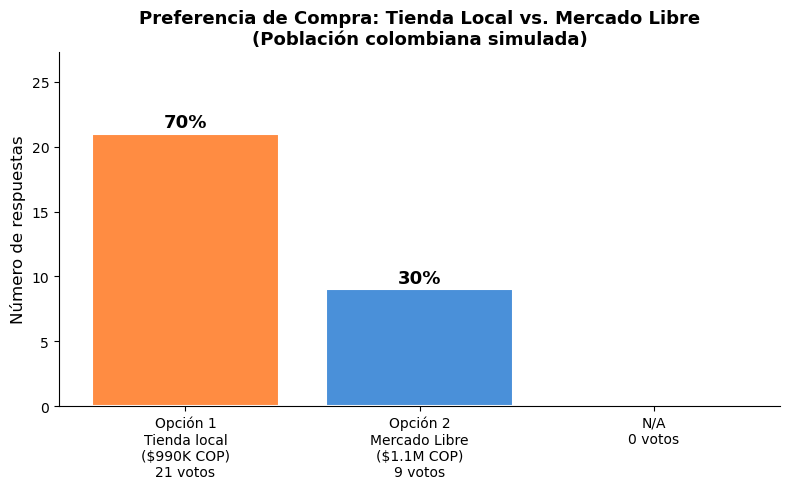


  RESULTADOS DE LA SIMULACIÓN DE PREFERENCIA DE COMPRA
  Total de respuestas: 30
  Opción 1 (tienda local, $990K): 21 (70%)
  Opción 2 (Mercado Libre, $1.1M): 9 (30%)



In [13]:
# Gráfico de distribución y resumen estadístico
analizar_resultados_simulacion(df)

In [14]:
# Análisis detallado de las razones de cada grupo
analizar_razones_por_grupo(df)


────────────────────────────────────────────────────────────
  Opción 1 – Tienda local ($990K COP)
  21 persona(s) eligieron esta opción
────────────────────────────────────────────────────────────

  1. Gloria Inés Rincón Herrera:
    Elige la tienda local porque es 110.000 COP más barata y además
    incluye instalación gratis; su situación económica hace que
    prefiera ahorrar, tomando precauciones como pedir recibo y probar
    la lavadora.

  2. Juana Ñusta Quispe Mamani:
    Prefiere la tienda local recomendada por un vecino porque es más
    barata y ofrece instalación gratis, y confía en la palabra de la
    comunidad; elegiría Mercado Libre solo si el vendedor local no
    inspira confianza o no se compromete formalmente.

  3. Jorge Elías Arango Toro:
    Prefiere la tienda del barrio por el menor precio y la instalación
    gratis, y porque confía en la recomendación del vecino dadas sus
    limitaciones económicas; además solicitaría un recibo y una nota
    escrita como

## Síntesis de razones clave por grupo (vía ResultsExtractor)

Las justificaciones individuales de cada agente son ricas pero extensas. A continuación, 
usamos `ResultsExtractor.extract_results_from_world()` para que el LLM analice el historial 
completo de interacciones de todos los agentes simultáneamente y sintetice las **razones 
comunes abstractas** de cada grupo — produciendo un resumen ejecutivo accionable.

In [15]:
# Configurar un ResultsExtractor orientado a sintetizar razones comunes por grupo.
# extract_results_from_world() analiza el historial completo de interacciones de
# todos los agentes de la audiencia y produce una síntesis estructurada.
reasons_extractor = ResultsExtractor(
    extraction_objective=(
        "Analizar las respuestas de TODOS los agentes a una encuesta de preferencia de compra "
        "y sintetizar las razones comunes de cada grupo. "
        "Grupo 1: agentes que eligieron la Opción 1 (tienda local, $990.000 COP). "
        "Grupo 2: agentes que eligieron la Opción 2 (Mercado Libre, $1.100.000 COP). "
        "Para cada grupo, identifica hasta 5 razones abstractas y representativas, "
        "ordenadas de más frecuente a menos frecuente. "
        "Las razones deben ser concisas (máximo 20 palabras cada una) y en español."
    ),
    situation=(
        "Los agentes fueron consultados sobre cuál oferta preferirían al comprar una lavadora: "
        "Opción 1 a $990.000 COP en tienda local de barrio (10% más barata, recomendada por vecino, "
        "instalación gratis, sin garantía formal), u Opción 2 a $1.100.000 COP en Mercado Libre "
        "(más costosa, con garantía formal, devolución fácil, financiación a 12 cuotas sin interés). "
        "Necesitamos entender los PATRONES de decisión de cada grupo."
    ),
    fields=[
        "option_1_count", "option_1_reasons",
        "option_2_count", "option_2_reasons"
    ],
    fields_hints={
        "option_1_count": "Número de agentes que eligieron la Opción 1 (tienda local).",
        "option_1_reasons": (
            "Lista de hasta 5 razones comunes (strings) del grupo que eligió Opción 1. "
            "Cada razón debe ser abstracta (no repetir palabras textuales de un agente), "
            "concisa (máx 20 palabras) y en español. Ordenar de más a menos frecuente."
        ),
        "option_2_count": "Número de agentes que eligieron la Opción 2 (Mercado Libre).",
        "option_2_reasons": (
            "Lista de hasta 5 razones comunes (strings) del grupo que eligió Opción 2. "
            "Cada razón debe ser abstracta, concisa (máx 20 palabras) y en español. "
            "Ordenar de más a menos frecuente."
        ),
    },
    verbose=True
)

# Extraer razones sintetizadas a partir del historial completo de la audiencia
razones = reasons_extractor.extract_results_from_world(audiencia)

# Presentar los resultados de forma legible
for opcion, key_count, key_reasons, label, emoji in [
    ("1", "option_1_count", "option_1_reasons", "Tienda local ($990K COP)", "🏪"),
    ("2", "option_2_count", "option_2_reasons", "Mercado Libre ($1.1M COP)", "🛒"),
]:
    count = razones.get(key_count, "?")
    reasons_list = razones.get(key_reasons, [])

    print(f"\n{'━'*60}")
    print(f"  {emoji}  GRUPO: {label}")
    print(f"  {count} persona(s) — Razones comunes sintetizadas:")
    print(f"{'━'*60}")

    for i, razon in enumerate(reasons_list[:5], 1):
        wrapped = textwrap.fill(str(razon), width=52, initial_indent="     ",
                                subsequent_indent="     ")
        print(f"\n  {i}. {wrapped.strip()}")

# Resumen ejecutivo
n1 = len(df[df["response"] == "1"])
n2 = len(df[df["response"] == "2"])
total = n1 + n2
if total > 0 and n1 > 0 and n2 > 0:
    print(f"\n{'═'*60}")
    print("  📋 RESUMEN EJECUTIVO PARA DECISIONES DE NEGOCIO")
    print(f"{'═'*60}")
    print(f"""
  Distribución: {n1}/{total} ({n1/total:.0%}) → Tienda local
                {n2}/{total} ({n2/total:.0%}) → Mercado Libre

  → El segmento que elige la tienda local prioriza el PRECIO
    y la CONFIANZA COMUNITARIA. Para captarlos en plataformas
    digitales: iguale precios, ofrezca pagos en efectivo/contra-
    entrega e instalación incluida.

  → El segmento que elige Mercado Libre valora la SEGURIDAD
    FORMAL y la FINANCIACIÓN. Para retenerlos: mantenga
    garantías claras, reputación visible y cuotas sin interés.
""")

Extraction raw result message: {'content': '{"option_1_count": 21, "option_1_reasons": ["Ahorro significativo frente a la alternativa online", "Instalación incluida que evita gasto y molestias", "Confianza en recomendaciones y trato personal del vendedor local", "Limitada o nula disponibilidad de tarjeta; prefieren pago en efectivo", "Mitigar riesgo pidiendo recibo, prueba y compromiso por escrito"], "option_2_count": 9, "option_2_reasons": ["Garantía formal y política de devolución clara", "Mayor seguridad y tranquilidad ante fallas o reparaciones", "Cuotas sin interés que facilitan el pago", "Reputación y historial del vendedor como respaldo", "Trazabilidad y procesos formales para reclamos y posventa"]}', 'refusal': None, 'role': 'assistant', 'annotations': []}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🏪  GRUPO: Tienda local ($990K COP)
  21 persona(s) — Razones comunes sintetizadas:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1. Ahorro sign

## Conclusiones

Este ejercicio demuestra cómo TinyTroupe puede generar una población sintética diversa 
y simular decisiones de compra realistas para un mercado específico (Colombia).

### Hallazgos esperados
- La población colombiana debería mostrar una **distribución mixta** de preferencias, 
  reflejando la diversidad socioeconómica del país.
- Factores como el **ingreso disponible**, la **confianza en el comercio digital**, 
  y la **sensibilidad al precio** son determinantes en la elección.
- Los consumidores de menores ingresos o con hábitos de compra tradicionales tienden 
  a preferir la tienda local, mientras que los consumidores urbanos con acceso a crédito 
  tienden a preferir Mercado Libre.

### Aplicaciones de negocio
- **Estrategia de precios**: Incluso una diferencia de ~$110.000 COP (10%) puede ser significativa 
  para ciertos segmentos de la población colombiana.
- **Confianza y reputación**: Las plataformas digitales deben invertir en construir 
  confianza, especialmente en segmentos que valoran la recomendación personal.
- **Inclusión financiera**: La opción de pago en efectivo sigue siendo relevante en 
  muchos segmentos del mercado colombiano.

---
*Notebook generado con [TinyTroupe](https://github.com/microsoft/TinyTroupe) — 
simulación de comportamiento humano basada en LLMs.*